#  GAT Nucleophilicity  — MCA prediction

GAT model predicting nucleophilicity (MCA)

summary:
- Atom features: 12-dim continuous
- Bond features: 6-dim (bond type × 4, conjugated, in-ring)
- Split: molecule-level 80/10/10, `numpy.default_rng(42)`, canonical SMILES, zero-overlap assertion
- Loss: `SmoothL1Loss` (Huber)
- Early stopping: patience=15
- Batch size: 64 
- `add_self_loops=False` in GATv2Conv (avoids OOM with edge_attr)

In [1]:
import pandas as pd
import os
import urllib.request
import tarfile

url          = "https://sid.erda.dk/share_redirect/c7LF5NaYvH"
archive_name = "data.tar.xz"
path_nuc     = "data/QMdata4ML/df_nuc.csv.gz"

if not os.path.exists(path_nuc):
    if not os.path.exists(archive_name):
        print("Downloading archive (~1.1 GB)...")
        urllib.request.urlretrieve(url, archive_name)
        print("Download complete.")
    print("Extracting archive...")
    with tarfile.open(archive_name, "r:xz") as tar:
        tar.extractall()
    print("Extraction complete.")

df_nuc = pd.read_csv(path_nuc)
print(f"Loaded {len(df_nuc)} rows.")
try:
    display(df_nuc.head())
except NameError:
    print(df_nuc.head())
print(df_nuc.shape)


Loaded 650857 rows.


,Unnamed: 0,smiles,nuc_sites,nuc_names,MCA_values,nuc_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,0,Amine,440.099103,"[-0.67701, -0.45662, 0.42243, 0.41945, 0.0, 0....",Train_fold4
1,1,NOCc1cccc(I)c1,4,double_bond,309.894963,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold3
2,2,NOCc1cccc(I)c1,5,double_bond,282.721295,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold1
3,3,NOCc1cccc(I)c1,6,double_bond,317.397119,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold2
4,4,NOCc1cccc(I)c1,9,double_bond,308.828194,"[-0.11146, 0.01492, -0.01706, 0.08581, 0.0, 0....",Train_fold3


(650857, 7)


In [2]:
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch_geometric.loader import DataLoader

from rdkit import Chem
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -- Reproducibility ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  import torch_geometric.typing
c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  import torch_geometric.typing
c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_nuc['MCA_values'] = pd.to_numeric(df_nuc['MCA_values'], errors='coerce')
df_nuc = df_nuc.dropna(subset=['smiles', 'MCA_values', 'nuc_sites'])
df_nuc['nuc_sites'] = df_nuc['nuc_sites'].astype(int)
df_nuc = df_nuc.reset_index(drop=True)
print(f"Rows after cleaning: {len(df_nuc)}")


Rows after cleaning: 650857


In [4]:
# Atom features  : 12 dimensions
#   atomic_num / 100, total_degree / 6, formal_charge / 5,
#   total_num_Hs / 4, is_aromatic, is_in_ring, is_target_site,
#   hybridisation one-hot x5  (SP / SP2 / SP3 / SP3D / SP3D2)
#
# Bond features  : 6 dimensions
#   bond_type one-hot x4  (SINGLE / DOUBLE / TRIPLE / AROMATIC),
#   is_conjugated, is_in_ring

HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

ATOM_FDIM = 7 + len(HYBRIDIZATION_TYPES)   # 12
BOND_FDIM = len(BOND_TYPES) + 2            # 6


def one_hot(value, choices):
    return [1.0 if value == c else 0.0 for c in choices]


def atom_features(atom: Chem.Atom, is_target_site: bool) -> list:
    return [
        atom.GetAtomicNum()   / 100.0,
        atom.GetTotalDegree() / 6.0,
        atom.GetFormalCharge()/ 5.0,
        atom.GetTotalNumHs()  / 4.0,
        float(atom.GetIsAromatic()),
        float(atom.IsInRing()),
        float(is_target_site),
    ] + one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES)


def bond_features(bond: Chem.Bond) -> list:
    return (one_hot(bond.GetBondType(), BOND_TYPES)
            + [float(bond.GetIsConjugated()), float(bond.IsInRing())])


def canonicalize_smiles(smi: str):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except Exception:
        return None


def mol_to_graph(smiles: str, site_index: int, mca_value: float):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    n_atoms = mol.GetNumAtoms()
    if site_index < 0 or site_index >= n_atoms:
        return None

    x = torch.tensor(
        [atom_features(a, a.GetIdx() == site_index) for a in mol.GetAtoms()],
        dtype=torch.float,
    )

    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs   += [bf, bf]

    if edge_indices:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attrs,   dtype=torch.float)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr  = torch.empty((0, BOND_FDIM), dtype=torch.float)

    site_mask = torch.tensor(
        [i == site_index for i in range(n_atoms)], dtype=torch.bool
    )

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                y=torch.tensor([mca_value], dtype=torch.float),
                site_mask=site_mask, smiles=smiles)

print(f"ATOM_FDIM = {ATOM_FDIM}  |  BOND_FDIM = {BOND_FDIM}")


ATOM_FDIM = 12  |  BOND_FDIM = 6


In [ ]:
# Molecule-level split: 80 / 10 / 10


TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

print("Canonicalising SMILES...")
df_nuc['canon_smiles'] = df_nuc['smiles'].apply(canonicalize_smiles)
df_nuc = df_nuc.dropna(subset=['canon_smiles']).reset_index(drop=True)

unique_mols = df_nuc['canon_smiles'].unique()
n_mols = len(unique_mols)
print(f"Unique molecules: {n_mols}  |  Sites (rows): {len(df_nuc)}")

rng  = np.random.default_rng(SEED)
perm = rng.permutation(n_mols)

train_end = int(TRAIN_FRAC * n_mols)
val_end   = int((TRAIN_FRAC + VAL_FRAC) * n_mols)

train_mols = set(unique_mols[perm[:train_end]])
val_mols   = set(unique_mols[perm[train_end:val_end]])
test_mols  = set(unique_mols[perm[val_end:]])

df_nuc['split'] = df_nuc['canon_smiles'].apply(
    lambda s: 'train' if s in train_mols else ('val' if s in val_mols else 'test')
)

# Zero-overlap assertion
for s1, s2 in [('train','val'), ('train','test'), ('val','test')]:
    overlap = (set(df_nuc.loc[df_nuc['split']==s1, 'canon_smiles']) &
               set(df_nuc.loc[df_nuc['split']==s2, 'canon_smiles']))
    assert len(overlap) == 0, f"Overlap detected between {s1} and {s2}!"
print("No SMILES overlap between splits.")

df_nuc[['canon_smiles', 'split']].drop_duplicates().to_csv('molecule_splits_nuc.csv', index=False)
print("molecule_splits_nuc.csv saved.")

print("\nRows per split:")
print(df_nuc['split'].value_counts().to_string())
print("\nUnique molecules per split:")
print(df_nuc.groupby('split')['canon_smiles'].nunique().to_string())


Canonicalising SMILES...
Unique molecules: 47921  |  Sites (rows): 650857
No SMILES overlap between splits.
molecule_splits_nuc.csv saved.

Rows per split:
split
train    521024
test      65132
val       64701

Unique molecules per split:
split
test      4793
train    38336
val       4792


In [6]:
train_df = df_nuc[df_nuc['split'] == 'train'].reset_index(drop=True)
val_df   = df_nuc[df_nuc['split'] == 'val'  ].reset_index(drop=True)
test_df  = df_nuc[df_nuc['split'] == 'test' ].reset_index(drop=True)

MCA_MEAN = train_df['MCA_values'].mean()
MCA_STD  = train_df['MCA_values'].std()
torch.save({'mean': MCA_MEAN, 'std': MCA_STD}, 'mca_normalization_gat.pt')
print(f"MCA mean (train): {MCA_MEAN:.3f}  |  std: {MCA_STD:.3f}")


def build_graphs(sub_df):
    graphs, skipped = [], 0
    for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
        y_norm = (float(row['MCA_values']) - MCA_MEAN) / MCA_STD
        g = mol_to_graph(row['smiles'], int(row['nuc_sites']), y_norm)
        if g is None:
            skipped += 1
        else:
            graphs.append(g)
    if skipped:
        print(f"  {skipped} graphs skipped (invalid SMILES or site index)")
    return graphs


print("Building graphs — train...")
train_list = build_graphs(train_df)
print("Building graphs — val...")
val_list   = build_graphs(val_df)
print("Building graphs — test...")
test_list  = build_graphs(test_df)

print(f"\nGraphs: train={len(train_list)}  val={len(val_list)}  test={len(test_list)}")

# Sanity check
for i, g in enumerate(train_list + val_list + test_list):
    assert g.x.shape[1] == ATOM_FDIM,         f"Graph {i}: x.shape={g.x.shape}"
    assert g.edge_attr.shape[1] == BOND_FDIM,  f"Graph {i}: edge_attr.shape={g.edge_attr.shape}"
    assert not g.x.isnan().any(),              f"Graph {i}: NaN in x"
    assert not g.edge_attr.isnan().any(),      f"Graph {i}: NaN in edge_attr"
print(f"{len(train_list)+len(val_list)+len(test_list)} graphs validated.")

BATCH_SIZE = 64
train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_list,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_list,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


MCA mean (train): 314.862  |  std: 72.874
Building graphs — train...


100%|██████████| 521024/521024 [05:13<00:00, 1663.32it/s]


Building graphs — val...


100%|██████████| 64701/64701 [00:38<00:00, 1676.04it/s]


Building graphs — test...


100%|██████████| 65132/65132 [00:40<00:00, 1606.72it/s]



Graphs: train=521024  val=64701  test=65132
650857 graphs validated.


In [7]:
class NucleoGAT(nn.Module):
    def __init__(self, num_node_features: int, edge_dim: int):
        super().__init__()
        self.conv1 = GATv2Conv(num_node_features, 64,  heads=4, edge_dim=edge_dim, add_self_loops=False)
        self.conv2 = GATv2Conv(64 * 4,            128, heads=4, edge_dim=edge_dim, add_self_loops=False)
        self.conv3 = GATv2Conv(128 * 4,           256, heads=1, edge_dim=edge_dim, add_self_loops=False)
        self.dropout = nn.Dropout(p=0.2)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)
        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)
        x = F.elu(self.conv3(x, edge_index, edge_attr))
        x = x[data.site_mask]
        x = F.elu(self.fc1(x))
        return self.fc2(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = NucleoGAT(num_node_features=ATOM_FDIM, edge_dim=BOND_FDIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Device: cuda
Trainable parameters: 573,697


In [8]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
criterion = nn.SmoothL1Loss()

best_val_loss = float('inf')
best_epoch    = -1
patience      = 15
counter       = 0
history       = []

out_dir = Path('outputs_nuc_gat')
out_dir.mkdir(exist_ok=True)

for epoch in range(1, 201):
    model.train()
    total_train_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        out  = model(data)
        loss = criterion(out.view(-1), data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_train_loss += loss.item() * data.num_graphs
    train_loss = total_train_loss / len(train_loader.dataset)

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out  = model(data)
            loss = criterion(out.view(-1), data.y)
            total_val_loss += loss.item() * data.num_graphs
    val_loss = total_val_loss / len(val_loader.dataset)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'lr': current_lr})

    print(f"Epoch {epoch:03d} | Train SmoothL1: {train_loss:.4f} | "
          f"Val SmoothL1: {val_loss:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save({
            'model_state_dict': model.state_dict(),
            'y_mean': MCA_MEAN,
            'y_std':  MCA_STD,
            'atom_fdim': ATOM_FDIM,
            'bond_fdim': BOND_FDIM,
        }, out_dir / 'best_nuc_gat.pt')
        counter = 0
        print("   -> Best model saved.")
    else:
        counter += 1
        print(f"   -> No improvement (patience: {counter}/{patience})")
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break

import pandas as pd
pd.DataFrame(history).to_csv(out_dir / 'training_history.csv', index=False)


Epoch 001 | Train SmoothL1: 0.1989 | Val SmoothL1: 0.1375 | LR: 1.00e-03
   -> Best model saved.
Epoch 002 | Train SmoothL1: 0.1358 | Val SmoothL1: 0.1242 | LR: 1.00e-03
   -> Best model saved.
Epoch 003 | Train SmoothL1: 0.1215 | Val SmoothL1: 0.1043 | LR: 1.00e-03
   -> Best model saved.
Epoch 004 | Train SmoothL1: 0.1105 | Val SmoothL1: 0.1092 | LR: 1.00e-03
   -> No improvement (patience: 1/15)
Epoch 005 | Train SmoothL1: 0.1043 | Val SmoothL1: 0.0953 | LR: 1.00e-03
   -> Best model saved.
Epoch 006 | Train SmoothL1: 0.0996 | Val SmoothL1: 0.0901 | LR: 1.00e-03
   -> Best model saved.
Epoch 007 | Train SmoothL1: 0.0957 | Val SmoothL1: 0.0883 | LR: 1.00e-03
   -> Best model saved.
Epoch 008 | Train SmoothL1: 0.0930 | Val SmoothL1: 0.0884 | LR: 1.00e-03
   -> No improvement (patience: 1/15)
Epoch 009 | Train SmoothL1: 0.0909 | Val SmoothL1: 0.0880 | LR: 1.00e-03
   -> Best model saved.
Epoch 010 | Train SmoothL1: 0.0888 | Val SmoothL1: 0.0931 | LR: 1.00e-03
   -> No improvement (pati

C:\Users\felic\AppData\Local\Temp\ipykernel_33668\3824398882.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(out_dir / 'best_nuc_gat.pt', map_loc

  NucleoGAT — Test Results
  R2   : 0.8784
  MAE  : 17.5008 kcal/mol
  RMSE : 25.2245 kcal/mol
  Test molecules : 4793
  Test sites     : 65132


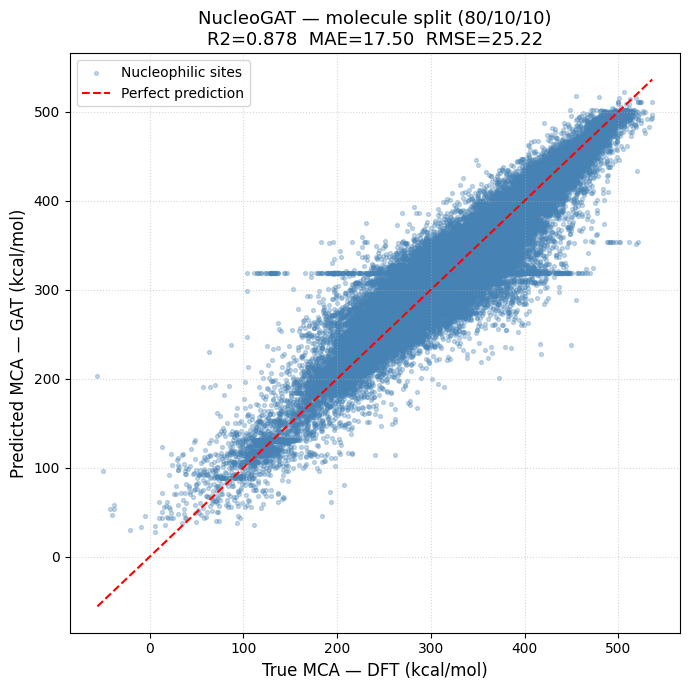

Results saved to C:\Users\felic\Downloads\outputs_nuc_gat


In [9]:
checkpoint = torch.load(out_dir / 'best_nuc_gat.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
MCA_MEAN = checkpoint['y_mean']
MCA_STD  = checkpoint['y_std']
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out  = model(data)
        all_preds.extend(out.view(-1).cpu().numpy())
        all_targets.extend(data.y.cpu().numpy())

all_preds   = np.array(all_preds)   * MCA_STD + MCA_MEAN
all_targets = np.array(all_targets) * MCA_STD + MCA_MEAN

r2   = r2_score(all_targets, all_preds)
mae  = mean_absolute_error(all_targets, all_preds)
rmse = math.sqrt(mean_squared_error(all_targets, all_preds))

print("=" * 50)
print("  NucleoGAT — Test Results")
print("=" * 50)
print(f"  R2   : {r2:.4f}")
print(f"  MAE  : {mae:.4f} kcal/mol")
print(f"  RMSE : {rmse:.4f} kcal/mol")
print("=" * 50)
print(f"  Test molecules : {test_df['canon_smiles'].nunique()}")
print(f"  Test sites     : {len(test_list)}")

plt.figure(figsize=(7, 7))
plt.scatter(all_targets, all_preds, alpha=0.3, s=8, color='steelblue', label='Nucleophilic sites')
lims = [min(all_targets.min(), all_preds.min()), max(all_targets.max(), all_preds.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('True MCA — DFT (kcal/mol)', fontsize=12)
plt.ylabel('Predicted MCA — GAT (kcal/mol)', fontsize=12)
plt.title(f"NucleoGAT — molecule split (80/10/10)\nR2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}", fontsize=13)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(out_dir / 'parity_plot_nuc_gat.png', dpi=200)
plt.show()

import pandas as pd
pd.DataFrame({'MCA_true': all_targets, 'MCA_pred': all_preds,
              'abs_error': np.abs(all_preds - all_targets)}).to_csv(
    out_dir / 'test_predictions_nuc_gat.csv', index=False)
print(f"Results saved to {out_dir.resolve()}")
